<a href="https://colab.research.google.com/github/nickcanoy/Masters_in_DataScience/blob/main/Discussion_1_1_3_Smoothing_CANOY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RODENICK CANOY | PSMDSSC 104-PSMDS12G2 - Advanced Data Science | Discussion 1.1.3 Smoothing

In [ ]:
#1. Load the Dataset (Google Drive)

import pandas as pd
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/AirTemp.csv')
df.head()

Mounted at /content/drive


,Date,T
0,3/10/2004,13.6
1,3/10/2004,13.3
2,3/10/2004,11.9
3,3/10/2004,11.0
4,3/10/2004,11.2


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['T'] = pd.to_numeric(df['T'], errors='coerce')

df_clean = df[df['T'] != -200].dropna()

In [ ]:
#2. Convert Into Pandas DataFrame & Clean Data

print("First 5 rows:")
display(df_clean.head())

print("Last 5 rows:")
display(df_clean.tail())

First 5 rows:


,Date,T
0,2004-03-10,13.6
1,2004-03-10,13.3
2,2004-03-10,11.9
3,2004-03-10,11.0
4,2004-03-10,11.2


Last 5 rows:


,Date,T
9352,2005-04-04,21.9
9353,2005-04-04,24.3
9354,2005-04-04,26.9
9355,2005-04-04,28.3
9356,2005-04-04,28.5


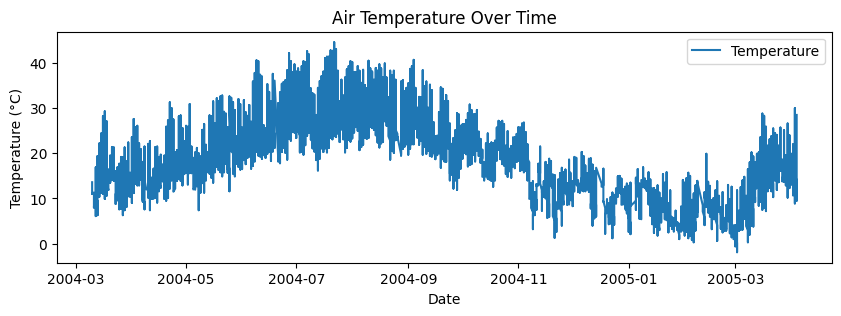

In [ ]:
#3. Plot the Dataset

import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(df_clean['Date'], df_clean['T'], label='Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Air Temperature Over Time')
plt.legend()
plt.show()

In [ ]:
#4. Exponential Smoothing Models

!pip install statsmodels

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

series = df_clean['T'].values


In [ ]:
#4.1 Single Exponential Smoothing (SES)

ses = SimpleExpSmoothing(series).fit()
ses_pred = ses.fittedvalues

In [ ]:
#4.2 Double Exponential Smoothing
#Additive Trend

des_add = ExponentialSmoothing(series, trend='add').fit()
des_add_pred = des_add.fittedvalues

In [ ]:
#Multiplicative Trend

# Add a shift so all values are positive
min_val = series.min()
shift_value = abs(min_val) + 1   # ensures positivity

series_shifted = series + shift_value

# Fit multiplicative trend
des_mul = ExponentialSmoothing(series_shifted, trend='mul').fit()

# Shift back after prediction
des_mul_pred = des_mul.fittedvalues - shift_value


In [ ]:
#4.3 Triple Exponential Smoothing (Holt–Winters)

tes_add = ExponentialSmoothing(
    series,
    trend='add',
    seasonal='add',
    seasonal_periods=365
).fit()

tes_add_pred = tes_add.fittedvalues

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [ ]:
#5. Model Performance Comparison (MSE, RMSE, MAE)

shift = abs(series.min()) + 1
series_shifted = series + shift

des_mul = ExponentialSmoothing(series_shifted, trend='mul').fit()
des_mul_pred = des_mul.fittedvalues - shift

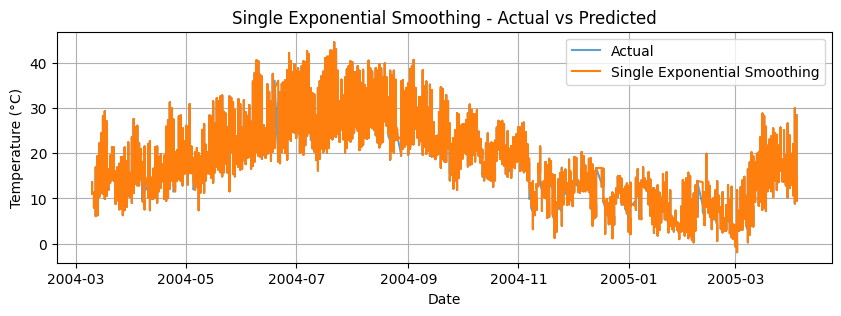

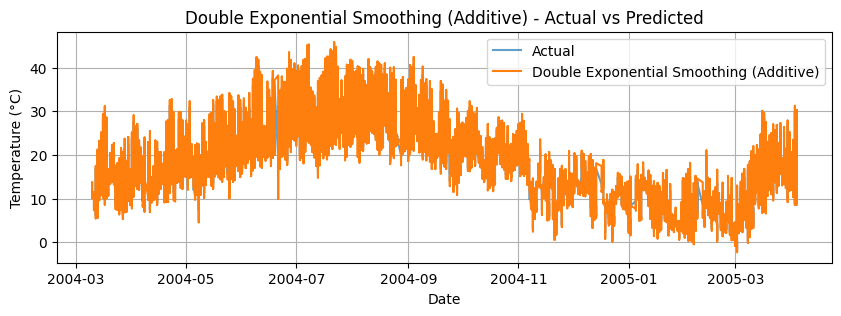

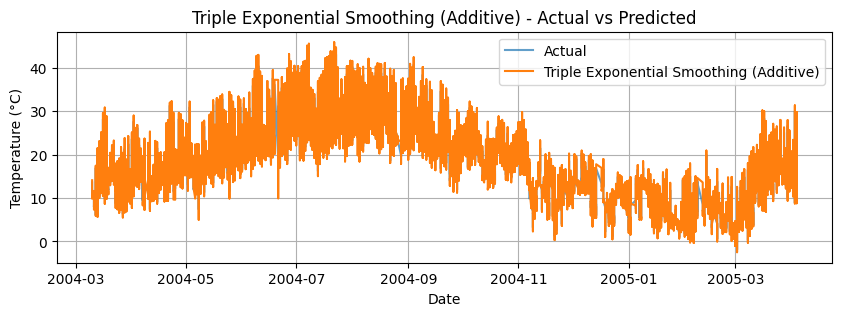

In [ ]:
def plot_model(pred, name):
    plt.figure(figsize=(10,3))
    plt.plot(df_clean['Date'], series, label='Actual', alpha=0.7)
    plt.plot(df_clean['Date'], pred, label=name)
    plt.title(name + " - Actual vs Predicted")
    plt.xlabel("Date")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_model(ses_pred, "Single Exponential Smoothing")
plot_model(des_add_pred, "Double Exponential Smoothing (Additive)")
plot_model(tes_add_pred, "Triple Exponential Smoothing (Additive)")
